In [ ]:
import os
try:
  from google.colab import drive
  drive.mount('/content/drive')
  os.chdir("/content/drive/MyDrive/COMP530-Project")
except ImportError:
  os.chdir("../data/processed")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
import pandas as pd
df = pd.read_csv(
    "AWID3_Parsed/Kr00k.csv",
    escapechar='\\',
    low_memory=False,
    skiprows=range(1, 1500000),
    # nrows=700000
    )

In [ ]:
desc_df = df.describe().T
filtered_df = desc_df[
    (desc_df['count'] >= 300000.0) &
    (desc_df['std'] > 0)
     ]
sorted_df = filtered_df.sort_values(by='std')
display(sorted_df)

,count,mean,std,min,25%,50%,75%,max
frame.time_delta_displayed,1400459.0,1.440536e-04,4.800763e-04,0.000000e+00,5.100000e-05,6.400000e-05,1.290000e-04,6.269500e-02
frame.time_delta,1400459.0,1.440536e-04,4.800763e-04,0.000000e+00,5.100000e-05,6.400000e-05,1.290000e-04,6.269500e-02
wlan.fc.type,1400459.0,9.156412e-01,6.725111e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
wlan_radio.phy,1400459.0,5.551781e+00,1.162107e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,8.000000e+00
wlan.fc.subtype,1400459.0,1.096008e+01,2.100133e+00,0.000000e+00,9.000000e+00,1.100000e+01,1.300000e+01,1.400000e+01
radiotap.length,1400459.0,5.740909e+01,3.051563e+00,4.800000e+01,5.600000e+01,5.600000e+01,5.600000e+01,6.400000e+01
radiotap.datarate,1143058.0,1.212315e+01,9.170212e+00,6.000000e+00,6.000000e+00,6.000000e+00,2.400000e+01,7.222222e+01
wlan_radio.signal_dbm,1400459.0,-4.990047e+01,1.625449e+01,-9.000000e+01,-6.900000e+01,-3.600000e+01,-3.600000e+01,-2.600000e+01
wlan_radio.data_rate,1400459.0,3.320946e+01,4.956375e+01,6.000000e+00,6.000000e+00,6.000000e+00,2.400000e+01,1.733333e+02
frame.time_relative,1400459.0,4.966910e+02,5.141256e+01,4.006465e+02,4.562542e+02,4.943086e+02,5.359456e+02,6.023876e+02


In [ ]:
import numpy as np

condition = (
    (df['wlan.fc.subtype'] == 10) &
    (df['wlan.fc.protected'] == 0) &
    (df['frame.number'] >= 1555898)
)

df['label'] = np.where(condition, 'kr00k', 'normal')

# Display the count of each label to verify
display(df['label'].value_counts())

,count
label,
normal,1208634
kr00k,191825


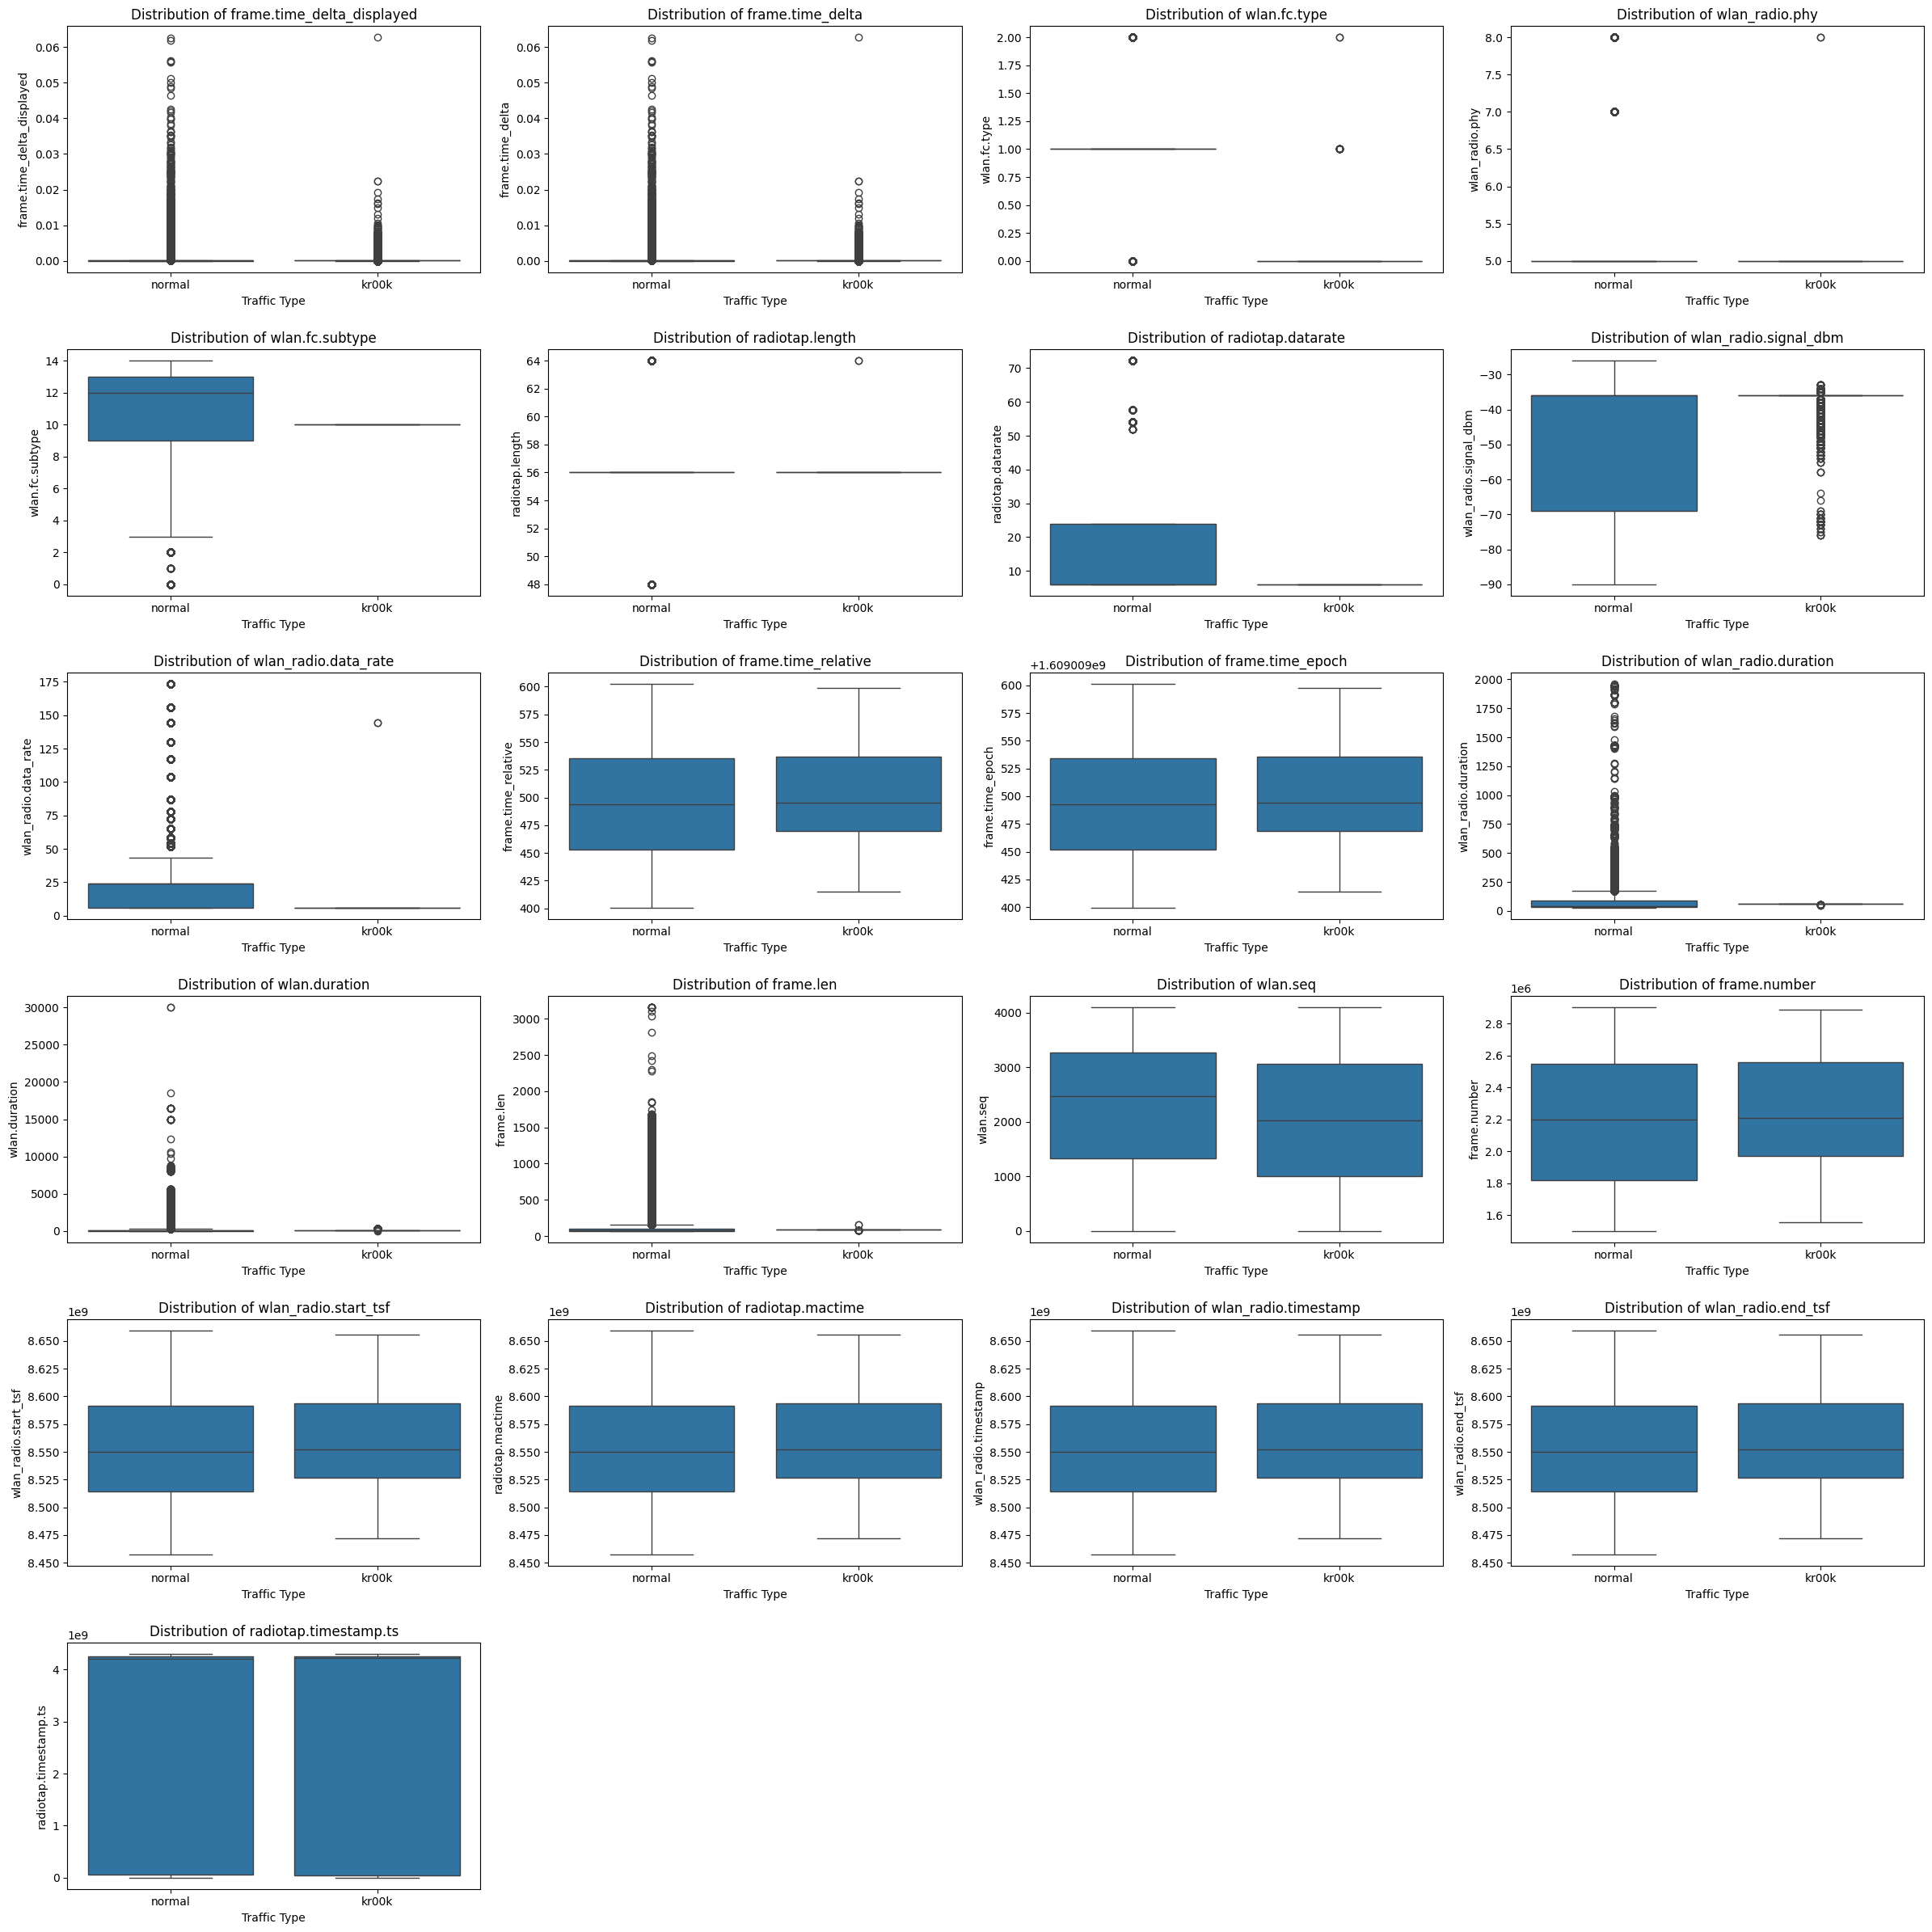

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of columns to plot from the index of sorted_df
columns_to_plot = sorted_df.index.tolist()

# Determine grid dimensions for subplots
num_columns = len(columns_to_plot)
num_cols_grid = 4  # Adjust as needed
num_rows_grid = (num_columns + num_cols_grid - 1) // num_cols_grid

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(num_cols_grid * 6, num_rows_grid * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(columns_to_plot):
    sns.boxplot(x='label', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Traffic Type')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()